<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## RNN many-to-one

#### Datos
El objecto es utilizar una serie de sucuencias númericas (datos sintéticos) para poner a prueba el uso de las redes RNN. Este ejemplo se inspiró en otro artículo, lo tienen como referencia en el siguiente link:\
[LINK](https://stackabuse.com/solving-sequence-problems-with-lstm-in-keras/)

In [2]:
import numpy as np

from keras.models import Sequential
from keras.layers import Dense, Input
from keras.layers import LSTM, SimpleRNN
from keras.layers import Bidirectional

In [6]:
# Generar datos sintéticos
X = list()
y = list()

# X será una lista de 1 a 45 agrupado de a 3 números consecutivos
# [ [1, 2, 3], [4, 5, 6], ....]
X = [[x, x + 1, x + 2] for x in range(1, 46, 3)]

# "y" (target) se obtiene como la suma de cada grupo de 3 números de entrada
y = [sum(x) for x in X]

print("datos X:", X)
print("datos y:", y)

datos X: [[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12], [13, 14, 15], [16, 17, 18], [19, 20, 21], [22, 23, 24], [25, 26, 27], [28, 29, 30], [31, 32, 33], [34, 35, 36], [37, 38, 39], [40, 41, 42], [43, 44, 45]]
datos y: [6, 15, 24, 33, 42, 51, 60, 69, 78, 87, 96, 105, 114, 123, 132]


In [8]:
# Cada dato X lo transformarmos en una matriz de 1 fila 1 columna (1x1)
X = np.array(X).reshape(len(X), len(X[0]), 1)
print("datos X:", X)

datos X: [[[ 1]
  [ 2]
  [ 3]]

 [[ 4]
  [ 5]
  [ 6]]

 [[ 7]
  [ 8]
  [ 9]]

 [[10]
  [11]
  [12]]

 [[13]
  [14]
  [15]]

 [[16]
  [17]
  [18]]

 [[19]
  [20]
  [21]]

 [[22]
  [23]
  [24]]

 [[25]
  [26]
  [27]]

 [[28]
  [29]
  [30]]

 [[31]
  [32]
  [33]]

 [[34]
  [35]
  [36]]

 [[37]
  [38]
  [39]]

 [[40]
  [41]
  [42]]

 [[43]
  [44]
  [45]]]


In [9]:
y = np.asanyarray(y)
y.shape

(15,)

### 2 - Entrenar el modelo

In [10]:
input_shape = X[0].shape
input_shape

(3, 1)

In [11]:
output_shape = 1
output_shape

1

In [13]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(SimpleRNN(64, activation="relu"))
model.add(Dense(output_shape))
model.compile(loss="mse", optimizer="Adam")

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
hist = model.fit(X, y, epochs=50, validation_split=0.2, batch_size=5)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 3242.2188 - val_loss: 11730.1836
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 3088.3655 - val_loss: 11104.9326
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2912.5872 - val_loss: 10490.2041
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2738.3918 - val_loss: 9892.3545
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2586.9768 - val_loss: 9237.0557
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2385.9692 - val_loss: 8598.6074
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2227.8274 - val_loss: 7928.6353
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2059.4775 - val_loss: 7210.9004
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1850.4462 - val_loss: 6446.3677
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1667.0468 - val_loss: 5636.0210
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1454.1577 - val_loss: 4805.2456
Epoch 12/50
3/3 

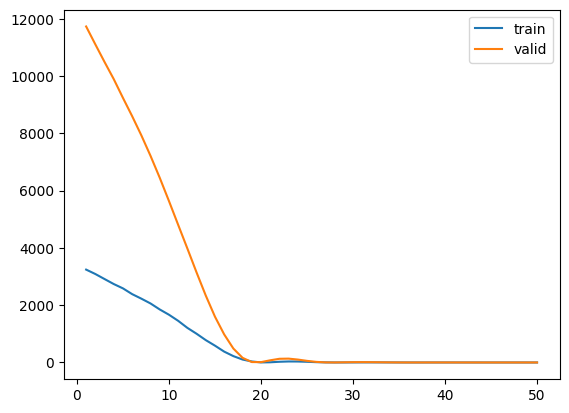

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamiento
epoch_count = range(1, len(hist.history["loss"]) + 1)
sns.lineplot(x=epoch_count, y=hist.history["loss"], label="train")
sns.lineplot(x=epoch_count, y=hist.history["val_loss"], label="valid")
plt.show()

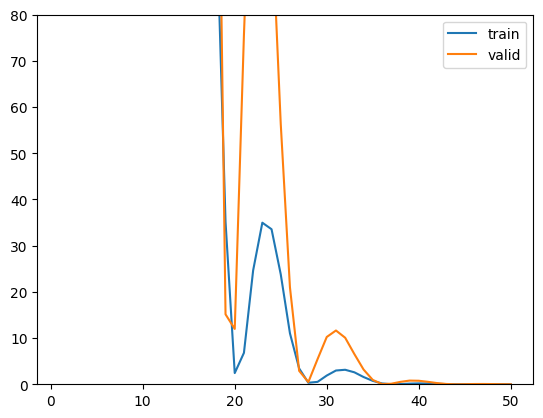

In [16]:
# Entrenamiento
epoch_count = range(1, len(hist.history["loss"]) + 1)
sns.lineplot(x=epoch_count, y=hist.history["loss"], label="train")
sns.lineplot(x=epoch_count, y=hist.history["val_loss"], label="valid")
plt.ylim(0, 80)
plt.show()

In [19]:
# Ensayo
x_test = [50, 51, 52]
y_test = sum(x_test)
test_input = np.array([x_test])
test_input = test_input.reshape((1, len(x_test), 1))
y_hat = model.predict(test_input, verbose=0)[0][0]

print("y_test:", y_test)
print("y_hat:", y_hat)

model.evaluate(test_input, np.array([y_test]))

y_test: 153
y_hat: 152.93701
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0040


0.0039675235748291016

### 3 - Bidirectional RNN (BRNN)

In [20]:
# En esta oportunidad se utilizará Bidirectional, dentro se especifica
# lo que se desea hacer, bidireccional es una capa LSTM

# En el summary se puede observar que la cantidad de parámetros
# de nuestor nueva capa LSTM bidireccional es el doble que la anterior

model2 = Sequential()
model2.add(Input(shape=input_shape))
model2.add(Bidirectional(SimpleRNN(64, activation="relu")))
model2.add(Dense(output_shape))
model2.compile(loss="mse", optimizer="Adam")

model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,577 (33.50 KB)

 Trainable params: 8,577 (33.50 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
hist2 = model2.fit(X, y, epochs=50, validation_split=0.2, batch_size=5)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - loss: 3767.8301 - val_loss: 12414.5811
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 3196.4600 - val_loss: 10476.0186
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2687.4893 - val_loss: 8764.9072
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2256.4807 - val_loss: 7214.8228
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1799.7408 - val_loss: 5810.9434
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1451.7933 - val_loss: 4485.1978
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1084.7565 - val_loss: 3277.4004
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 815.4708 - val_loss: 2208.4895
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 521.0615 - val_loss: 1343.1302
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 289.4992 - val_loss: 675.9007
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 150.1143 - val_loss: 219.5690
Epoch 12/50
3/3 ━━━━━━

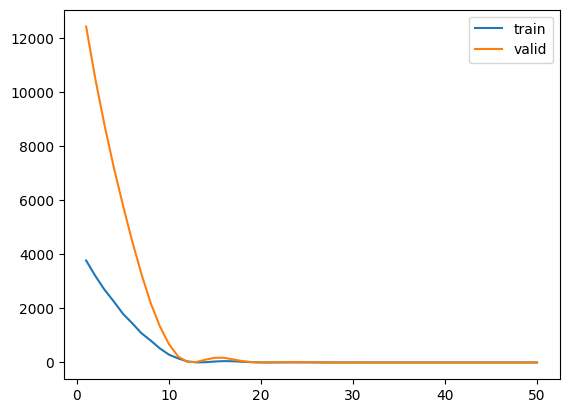

In [22]:
# Entrenamiento
epoch_count = range(1, len(hist2.history["loss"]) + 1)
sns.lineplot(x=epoch_count, y=hist2.history["loss"], label="train")
sns.lineplot(x=epoch_count, y=hist2.history["val_loss"], label="valid")
plt.show()

In [24]:
# Ensayo
x_test = [50, 51, 52]
y_test = sum(x_test)
test_input = np.array([x_test])
test_input = test_input.reshape((1, len(x_test), 1))
y_hat = model2.predict(test_input, verbose=0)[0][0]

print("y_test:", y_test)
print("y_hat:", y_hat)

model2.evaluate(test_input, np.array([y_test]))

y_test: 153
y_hat: 152.56032
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1933


0.19332027435302734

📝 Para predecir la **siguiente palabra**, es mas conveniente utilizar la SimpleRNN ya que con la Bidirectional se estaría utilizando información del futuro.

### 5 - Otras estructuras

In [25]:
model3 = Sequential()
model3.add(Input(shape=input_shape))
model3.add(
    SimpleRNN(64, activation="relu", return_sequences=True)
)  # return_sequences=True devuelve cada salida, no solo la última
model3.add(SimpleRNN(64, activation="relu"))
model3.add(Dense(output_shape))
model3.compile(loss="mse", optimizer="Adam")

model3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 3, 64)          │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,545 (49.00 KB)

 Trainable params: 12,545 (49.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model4 = Sequential()
model4.add(Input(shape=input_shape))
model4.add(LSTM(64, activation="relu"))
model4.add(Dense(output_shape))
model4.compile(loss="mse", optimizer="Adam")
model4.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

### 5 - Conclusión
Implementar un modelo bidireccional basado en RNN es muy sensillo. En este ejemplo no se explotó su potencialidad pero queda como nota de como implementar una capa BRNN.